In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Veriyi yükle
from google.colab import files
uploaded = files.upload()

Saving SampleSuperstore.csv to SampleSuperstore.csv


# Superstore Sales Analysis
## Overview
This project analyzes sales, profit, and discount patterns
of a retail superstore across regions, categories, and customer segments.

## Key Findings:
- West region generates the highest sales ($725K)
- Technology is the most profitable category (17.4% margin)
- High discounts (>40%) consistently lead to losses
- Tables and Bookcases are loss-making sub-categories

In [3]:
df = pd.read_csv('SampleSuperstore.csv', encoding='latin-1')
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [4]:
# Veri hakkında genel bilgi
print("Shape:", df.shape)
print("\nColumn Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nBasic Statistics:\n", df.describe())

Shape: (9994, 13)

Column Types:
 Ship Mode        object
Segment          object
Country          object
City             object
State            object
Postal Code       int64
Region           object
Category         object
Sub-Category     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

Missing Values:
 Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

Basic Statistics:
         Postal Code         Sales     Quantity     Discount       Profit
count   9994.000000   9994.000000  9994.000000  9994.000000  9994.000000
mean   55190.379428    229.858001     3.789574     0.156203    28.656896
std    32063.693350    623.245101     2.225110     0.206452   234.260108
min     1040.000000      0.444000     1.000000     0.000000 -65

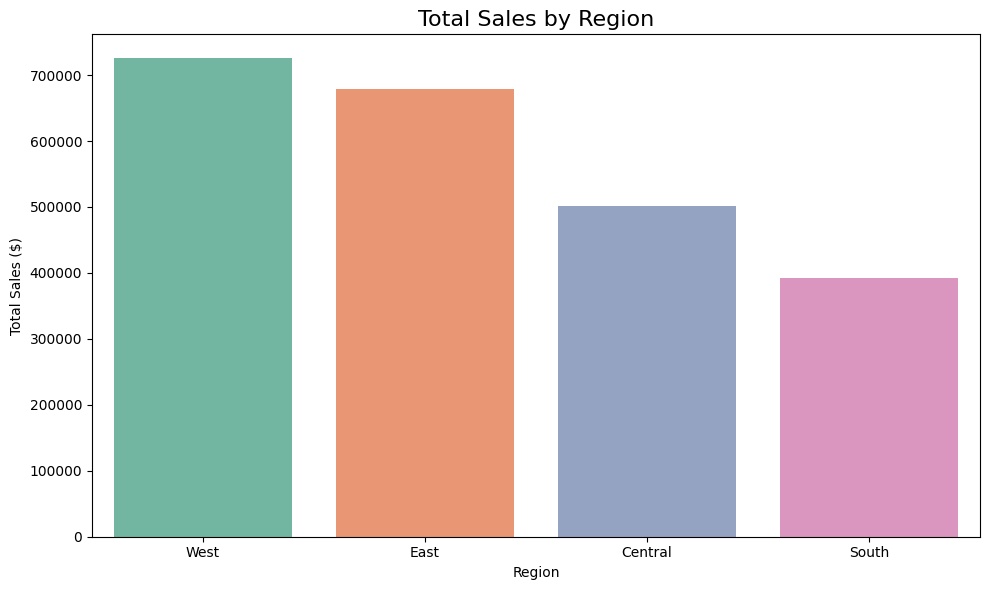

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


In [6]:
# Sales by Region
plt.figure(figsize=(10, 6))
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=region_sales.index, y=region_sales.values,
            hue=region_sales.index, palette='Set2', legend=False)
plt.title('Total Sales by Region', fontsize=16)
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

print(region_sales)

## 1. Sales by Region
Analyzing total sales across four regions to identify
the highest performing region.


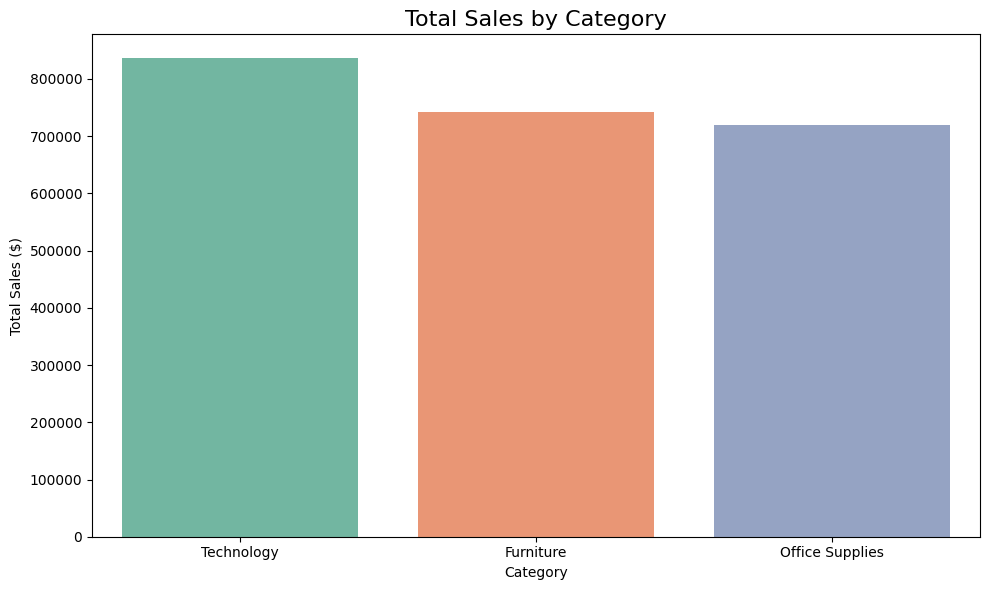

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64


In [7]:
# Sales by Category
plt.figure(figsize=(10, 6))
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
sns.barplot(x=category_sales.index, y=category_sales.values,
            hue=category_sales.index, palette='Set2', legend=False)
plt.title('Total Sales by Category', fontsize=16)
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

print(category_sales)

## 2. Sales & Profit by Category
Comparing sales and profit margins across three main categories.
Note: Furniture has high sales but very low profit margin (2.5%).

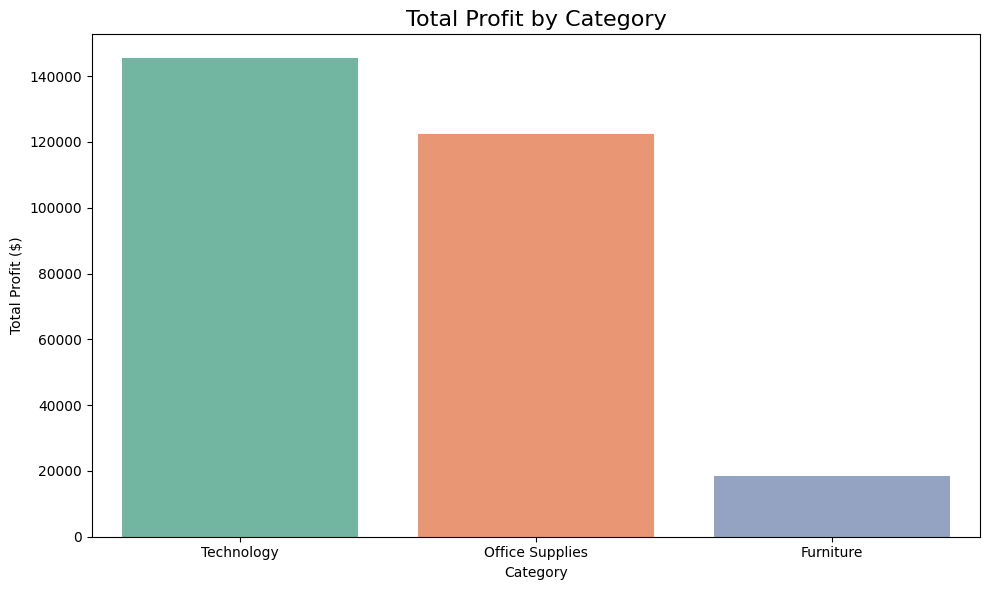

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


In [8]:
# Profit by Category
plt.figure(figsize=(10, 6))
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
sns.barplot(x=category_profit.index, y=category_profit.values,
            hue=category_profit.index, palette='Set2', legend=False)
plt.title('Total Profit by Category', fontsize=16)
plt.xlabel('Category')
plt.ylabel('Total Profit ($)')
plt.tight_layout()
plt.show()

print(category_profit)

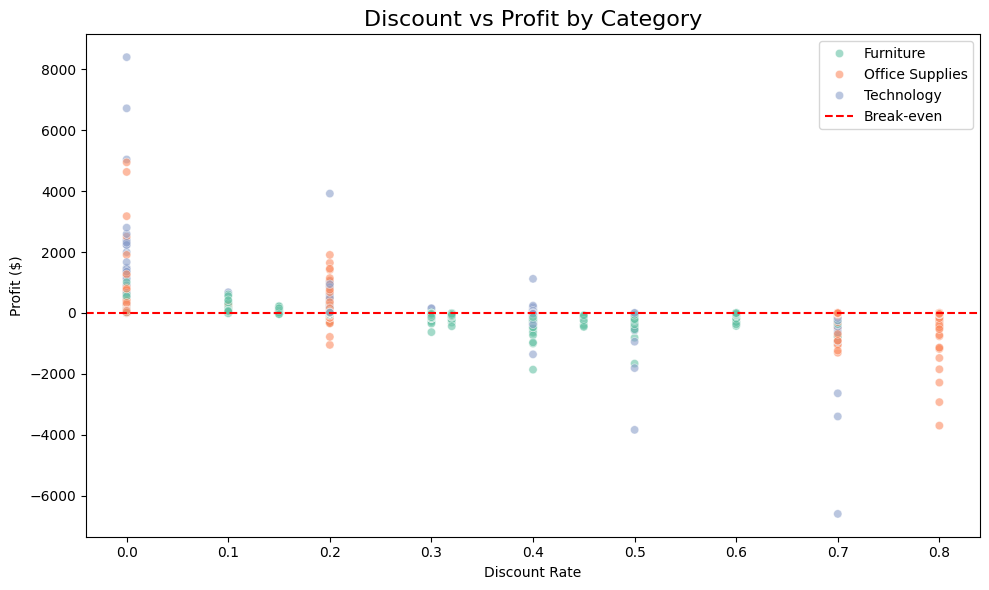

In [9]:
# Discount vs Profit
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Discount', y='Profit',
                hue='Category', palette='Set2', alpha=0.6)
plt.title('Discount vs Profit by Category', fontsize=16)
plt.xlabel('Discount Rate')
plt.ylabel('Profit ($)')
plt.axhline(y=0, color='red', linestyle='--', label='Break-even')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Discount vs Profit Analysis
Examining the relationship between discount rates and profitability.
Key Finding: Discounts above 40% consistently result in losses.

In [11]:
# Kolon isimlerini kontrol et
print(df.columns.tolist())

['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Profit']


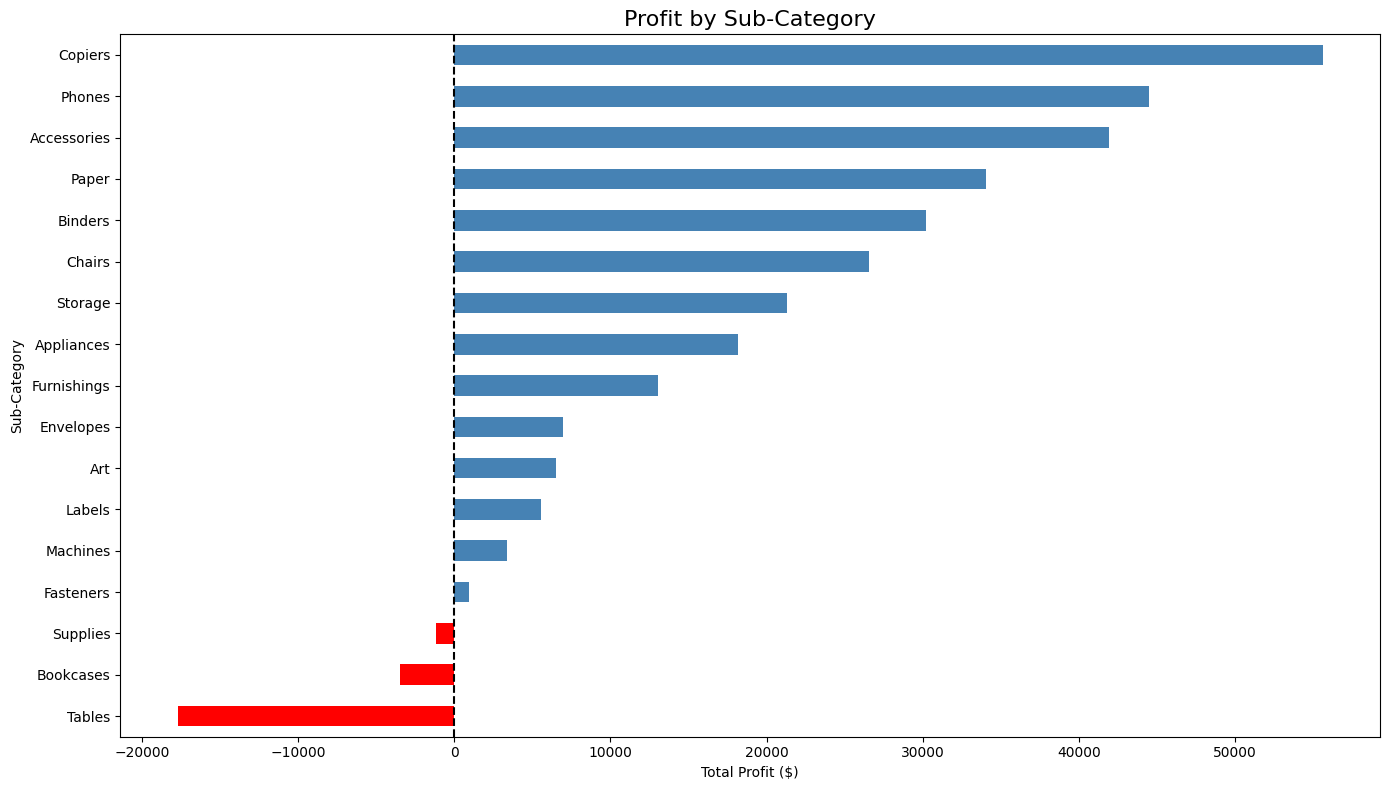

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Storage        21278.8264
Chairs         26590.1663
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64


In [12]:
# Profit by Sub-Category
plt.figure(figsize=(14, 8))
subcategory_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
colors = ['red' if x < 0 else 'steelblue' for x in subcategory_profit.values]
subcategory_profit.plot(kind='barh', color=colors)
plt.title('Profit by Sub-Category', fontsize=16)
plt.xlabel('Total Profit ($)')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

print(subcategory_profit)

## 4. Profit by Sub-Category
Identifying which sub-categories are profitable and which are losing money.
Key Finding: Tables (-$17,725) and Bookcases (-$3,472) are loss-making.

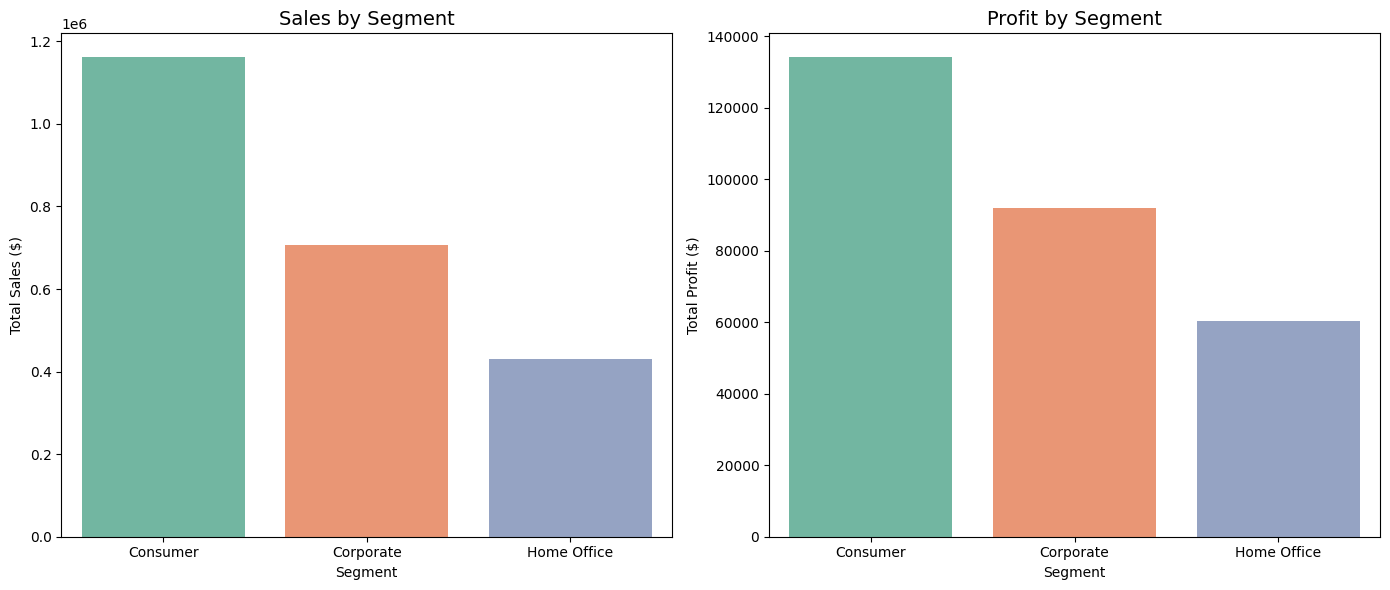

Sales:
 Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

Profit:
 Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64


In [13]:
# Sales and Profit by Segment
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
segment_profit = df.groupby('Segment')['Profit'].sum().sort_values(ascending=False)

sns.barplot(x=segment_sales.index, y=segment_sales.values,
            hue=segment_sales.index, palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Sales by Segment', fontsize=14)
axes[0].set_ylabel('Total Sales ($)')

sns.barplot(x=segment_profit.index, y=segment_profit.values,
            hue=segment_profit.index, palette='Set2', legend=False, ax=axes[1])
axes[1].set_title('Profit by Segment', fontsize=14)
axes[1].set_ylabel('Total Profit ($)')

plt.tight_layout()
plt.show()

print("Sales:\n", segment_sales)
print("\nProfit:\n", segment_profit)

## 5. Sales & Profit by Segment
Analyzing performance across Consumer, Corporate, and Home Office segments.